## Princípios de Eletromag no Sionna

referênica: [Link Tutorial Oficial](https://nvlabs.github.io/sionna/rt/em_primer.html#coordinate-system-rotations-and-vector-fields)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Direciona o interpretador para pasta onde estao os arquivos
%cd "/content/drive/MyDrive/Estudos/UFRN/POSGRADUACAO/2025.2/RADIOPROPAGACAO/Aprendendo Sionna"
!pwd


/content/drive/MyDrive/Estudos/UFRN/POSGRADUACAO/2025.2/RADIOPROPAGACAO/Aprendendo Sionna
/content/drive/MyDrive/Estudos/UFRN/POSGRADUACAO/2025.2/RADIOPROPAGACAO/Aprendendo Sionna


In [1]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = False # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, PlanarArray

In [2]:
# Load integrated scene
# scene = load_scene(sionna.rt.scene.munich) # Try also sionna.rt.scene.etoile
# scene = load_scene("will_testes.xml")
scene = load_scene("LAB_MODEL.xml")
# scene = load_scene(sionna.rt.scene.simple_street_canyon, merge_shapes=False)

In [3]:
list(scene.radio_materials.keys())

['itu_wood', 'itu_concrete', 'itu_glass']

In [4]:
if not no_preview:
    scene.preview();

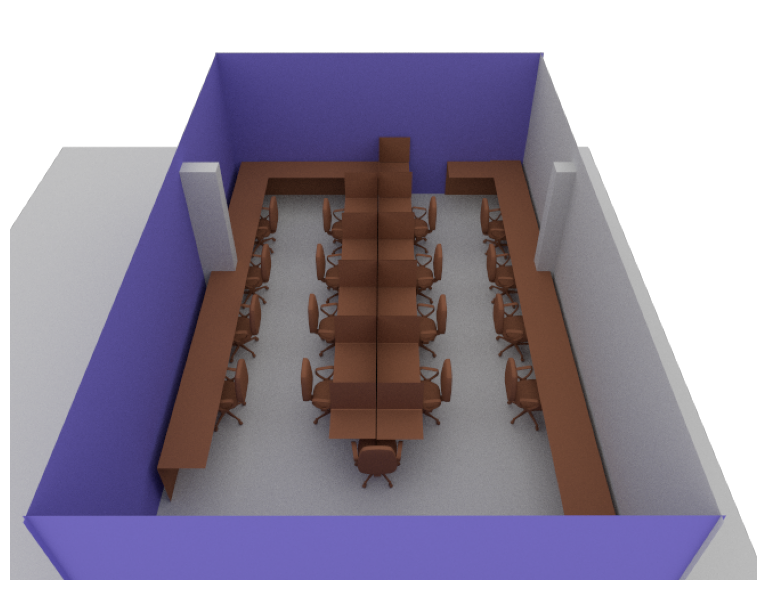

In [6]:
# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

In [7]:
# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

In [8]:

cam = Camera(position=[-360,145,200], look_at=[-115,33,1.5])
if no_preview:
    scene.render(camera=cam, resolution=[650, 500], num_samples=512);
else:
    scene.preview();

In [27]:
print(type(scene.objects))
scene.objects

<class 'dict'>


{'no-name-9': <sionna.rt.scene_object.SceneObject at 0x272c0bbe270>,
 'no-name-10': <sionna.rt.scene_object.SceneObject at 0x272c0bbda00>,
 'no-name-11': <sionna.rt.scene_object.SceneObject at 0x272c0e2fb60>}

In [28]:
for chave, valor in scene.objects.items():
    print(f"{chave}: {valor}")
    floor = scene.get(chave)
    print("Position (x,y,z) [m]: ", floor.position)
    print("Orientation (alpha, beta, gamma) [rad]: ", floor.orientation)
    print("Scaling: ", floor.scaling)

no-name-9: <sionna.rt.scene_object.SceneObject object at 0x00000272C0BBE270>
Position (x,y,z) [m]:  [[4.37825, 2.94517, 0.4]]
Orientation (alpha, beta, gamma) [rad]:  [[0, 0, 0]]
Scaling:  [[1, 1, 1]]
no-name-10: <sionna.rt.scene_object.SceneObject object at 0x00000272C0BBDA00>
Position (x,y,z) [m]:  [[4.44004, 2.8896, 1.5]]
Orientation (alpha, beta, gamma) [rad]:  [[0, 0, 0]]
Scaling:  [[1, 1, 1]]
no-name-11: <sionna.rt.scene_object.SceneObject object at 0x00000272C0E2FB60>
Position (x,y,z) [m]:  [[4.79562, 4.12077, 1.5]]
Orientation (alpha, beta, gamma) [rad]:  [[0, 0, 0]]
Scaling:  [[1, 1, 1]]


In [9]:
import pandas as pd
import numpy as np

# Lê o arquivo CSV
df = pd.read_csv("lab1 - Rappaport.csv")

# Extrai as colunas X e Y (ajuste os nomes se necessário)
x = df["X (m)"].values
y = df["Y (m)"].values

# Define Z fixo (0.8 m)
z = np.full_like(x, 0.8)

# Monta o array de posições (N x 3)
rx_positions = np.column_stack((x, y, z))

# Exibe o resultado
print(rx_positions)

[[0.   0.   0.8 ]
 [1.   0.   0.8 ]
 [2.   0.   0.8 ]
 [3.   0.   0.8 ]
 [4.   0.   0.8 ]
 [5.   0.   0.8 ]
 [6.   0.   0.8 ]
 [7.   0.   0.8 ]
 [8.   0.   0.8 ]
 [9.   0.   0.8 ]
 [0.   1.16 0.8 ]
 [1.   1.16 0.8 ]
 [2.   1.16 0.8 ]
 [3.   1.16 0.8 ]
 [4.   1.16 0.8 ]
 [5.   1.16 0.8 ]
 [6.   1.16 0.8 ]
 [7.   1.16 0.8 ]
 [8.   1.16 0.8 ]
 [9.   1.16 0.8 ]
 [0.   2.32 0.8 ]
 [1.   2.32 0.8 ]
 [2.   2.32 0.8 ]
 [3.   2.32 0.8 ]
 [4.   2.32 0.8 ]
 [5.   2.32 0.8 ]
 [6.   2.32 0.8 ]
 [7.   2.32 0.8 ]
 [8.   2.32 0.8 ]
 [9.   2.32 0.8 ]
 [0.   3.48 0.8 ]
 [1.   3.48 0.8 ]
 [2.   3.48 0.8 ]
 [3.   3.48 0.8 ]
 [4.   3.48 0.8 ]
 [5.   3.48 0.8 ]
 [6.   3.48 0.8 ]
 [7.   3.48 0.8 ]
 [8.   3.48 0.8 ]
 [9.   3.48 0.8 ]
 [0.   4.64 0.8 ]
 [1.   4.64 0.8 ]
 [2.   4.64 0.8 ]
 [3.   4.64 0.8 ]
 [4.   4.64 0.8 ]
 [5.   4.64 0.8 ]
 [6.   4.64 0.8 ]
 [7.   4.64 0.8 ]
 [8.   4.64 0.8 ]
 [9.   4.64 0.8 ]
 [0.   5.8  0.8 ]
 [1.   5.8  0.8 ]
 [2.   5.8  0.8 ]
 [3.   5.8  0.8 ]
 [4.   5.8  0.8 ]
 [5.   5.8

In [26]:

# rx_positions=None
def config_scene(rx_positions=None):
    """Load and configure a scene"""
    scene = load_scene("LAB_MODEL.xml")
    # scene = load_scene()
    scene.bandwidth=3.2e6

    # Configure antenna arrays for all transmitters and receivers
    scene.tx_array = PlanarArray(num_rows=1,
                                 num_cols=2,
                                 pattern="tr38901",
                                 polarization="V")

    scene.rx_array = PlanarArray(num_rows=1,
                                 num_cols=1,
                                 pattern="iso",
                                 polarization="V")

    if rx_positions is None:
      # Configure receivers
      rx_positions = np.array([
          [6, 2, 1],
          # Adicione mais receptores aqui, se quiser
          # [x, y, z],
      ])
    
    rx_names = [f"rx{i}" for i in range(len(rx_positions))]

    for i, position in enumerate(rx_positions):
        rx = Receiver(name=rx_names[i], position=position)
        scene.add(rx)


    # [1.036, 0.677, 1.870]
    # (0.755, 0.365, 2.513)
    # Place transmitters
    positions = np.array(
                 [(0.755, 0.365, 2.513),

                 ])
    look_ats = np.array(
                [[9,1,4],

                ])
    power_dbms = [5]

    for i, position in enumerate(positions):
        scene.add(Transmitter(name=f'tx{i}',
                              position=position,
                              look_at=look_ats[i],
                              power_dbm=power_dbms[i]))

    return scene


# Render an image
# cam = Camera(position=[0,0,20],
#                     orientation=np.array([0,np.pi/2,-np.pi/2]))
cam = Camera(position=[-10,10,20], look_at=[5,2,0])
# Load and configure scene
scene_etoile = config_scene(rx_positions)
# scene_etoile.preview()
# Compute the SINR map
rm_solver = RadioMapSolver()
rm_etoile = rm_solver(scene_etoile,
                      max_depth=5,
                      samples_per_tx=10**7,
                      cell_size=(0.1, 0.1),
                      center=[4.5, 3, 0.8],
                      size=[9, 6],
                      orientation=[0, 0, 0])
if not no_preview:
  scene_etoile.preview(radio_map=rm_etoile,
                          rm_metric="sinr",
                          rm_vmin=-20,
                          rm_vmax=50)
else:
  rm_etoile.show(metric="rss");
  rm_etoile.show(metric="path_gain");
  # rm_etoile.show(metric="sinr");

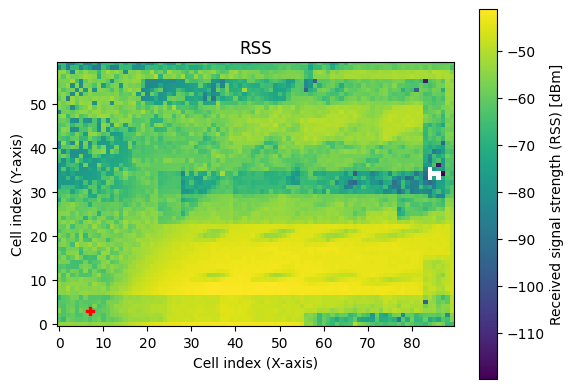

In [27]:
rm_etoile.show(metric="rss");

In [ ]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene_etoile,
                 max_depth=2,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)


In [ ]:
if no_preview:
    scene.render(camera=cam, paths=paths, clip_at=2);
else:
    scene.preview(paths=paths, clip_at=2);

In [ ]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

# And plot the CIR
plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");

In [ ]:
rm_etoile.show(metric="sinr");
scene.render(camera=cam, resolution=[650, 500], paths=paths, num_samples=512);